<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/20260417%2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
# 데이터셋을 무작위로 샘플링할때 쓰려고(train/test)
from torch.utils.data.sampler import SubsetRandomSampler


In [23]:
# cuda : gpu 쓰기위한 도구(플랫폼)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [24]:
# root=데이터저장경로
# MNIST 이미지 (1,28,28) -> ToTensor(텐서로 변환) (0~1)
train_data=datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data=datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

In [25]:
print(train_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [26]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [27]:
print(train_data[0]) # (image, label)
print(train_data[0][0]) # image
print(train_data[0][1]) # label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

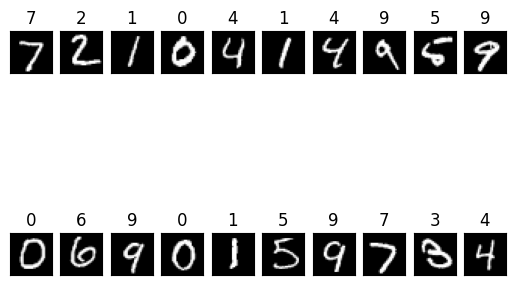

In [28]:
# i : 인덱스
# (x,y) => (image, label)
for i, (x,y) in enumerate(test_data):
  if i>19:
    break

  plt.subplot(2,10,i+1)
  plt.imshow(x.view(28,28), cmap="gray")
  plt.title(y)
  plt.xticks([])
  plt.yticks([])
plt.show()

In [29]:
in_data=list(range(60000)) # [0,1, ..... 59999]
np.random.shuffle(in_data) # 번호표를 무작위로 섞어놓음
split_data=int(np.floor(0.2*60000)) # 12000개는 train-validation용으로 설정 48000개는 train용

# train_index : 12001번째부터 마지막까지(48000개) - 학습용
# valid_index : 처음부터 12000번째까지(12000개) - 검증용
train_index, valid_index=in_data[split_data:], in_data[:split_data]

In [30]:
# 주어진 인덱스 리스트에서 무작위 순서로 데이터 샘플링하려고
train_sample=SubsetRandomSampler(train_index)
valid_sample=SubsetRandomSampler(valid_index)

In [31]:
from torch.utils.data import DataLoader

In [32]:
# SubsetRandomSampler - DataLoader
# DataLoader 가 다음 값 요청하면 샘플러가 인덱스 하나를 무작위로 던져주는 구조(호환됨)
train_loader=DataLoader(train_data, batch_size=128, sampler=train_sample)
vaild_loader=DataLoader(train_data, batch_size=128, sampler=valid_sample)
# 60000개를 무작위로 섞은 후 80% 학습 20% 검즘용으로 나눔

test_loader=DataLoader(test_data, batch_size=128, shuffle=False) # 10000개

In [33]:
from torch.autograd import forward_ad
# 레이어 정의
class Mnist1(nn.Module):
  def __init__(self, in_dim, hidden_dim, out_dim):
    super().__init__()
    self.f1=nn.Linear(in_dim, hidden_dim) # 입력 -> 은닉1
    self.f2=nn.Linear(hidden_dim, hidden_dim) # 은닉1 -> 은닉2
    self.f3=nn.Linear(hidden_dim, out_dim) # 은닉2 -> 출력
    self.dropout=nn.Dropout(0.2) # 과적합 방지용 드롭아웃 0.2 => 20% 노드는 무작위로 비활성화 된다
    self.relu=nn.ReLU()

    # f1 -> relu -> dropout -> f2 -> relu -> dropout -> f3 -> 출력층 -> softmax -> 확률분포에 따라 예측
    # 순전파
  def forward(self, x):
    x=self.relu(self.f1(x))
    x=self.dropout(x)
    x=self.relu(self.f2(x))
    x=self.dropout(x)
    # 최종 클래스 확률 계산 안정적으로 하기위해 dropout 안함
    out=self.f3(x)
    return out

In [34]:
in_dim=28*28 # 784개
hidden_dim=128
out_dim=10 # 10개 숫자

In [35]:
model=Mnist1(in_dim, hidden_dim, out_dim)
model

Mnist1(
  (f1): Linear(in_features=784, out_features=128, bias=True)
  (f2): Linear(in_features=128, out_features=128, bias=True)
  (f3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

In [36]:
# 1장의 이미지를 모델에 넣어 출력값 계산 -> torch.Size([1, 28, 28]) -> __call__ -> forward
for image, label in train_loader:
  image_trans=model(image[0].view(-1, 28*28))
  break

print(image_trans) # 0~9까지 수에서 0일 확률을 -0.0287 , 1일 확률은 -0.0781
print(image_trans.shape)
# 텐서에서 계산(gradient)없이 값만 가져올때
print(image_trans[0].data)
prediction=torch.argmax(image_trans, dim=1)
print(prediction)


tensor([[ 0.0129, -0.0851,  0.0110,  0.0215, -0.0050, -0.0427,  0.0408, -0.0158,
          0.0328, -0.0712]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])
tensor([ 0.0129, -0.0851,  0.0110,  0.0215, -0.0050, -0.0427,  0.0408, -0.0158,
         0.0328, -0.0712])
tensor([6])


In [37]:
# 다중 분류에서 가장 많이 쓰이는 손실함수
crossloss=nn.CrossEntropyLoss()
# 모델을 cpu로 올린 후에 입력데이터도 cpu로 이동시킴
model.to(device)

Mnist1(
  (f1): Linear(in_features=784, out_features=128, bias=True)
  (f2): Linear(in_features=128, out_features=128, bias=True)
  (f3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

In [38]:
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [40]:
loss1, acc1=[], []
for epoch in range(50):
  t_loss=0 # 손실 초기화
  t_acc=0 # 정확도 초기화

  for i,j in train_loader:
    i,j=i.to(device), j.to(device)
    z=model(i.view(-1,28*28)) # 모델에 이미지 넣어서 예측값 계산하라고 -> forward
    loss=crossloss(z,j) # CrossEntropyLoss 통해 모델 예측값과 실제 정답사이의 오차
    t_loss+=loss.item()
    # 가장 높은 점수를 뽑아내지 않고, 그게 몇번 클래스인지 알아내기 위해서
    _,y_pred=torch.max(z,1) # 가장 높은 점수를 가진 클래스 인덱스 => (_ : 최대값, y_pred :예측 클래스 번호)
    t_acc+=(y_pred==j).sum().item()

    optimizer.zero_grad() # 기울기 초기화
    loss.backward() # 기울기 계산
    optimizer.step() # 가중치 업데이트

  t_loss=t_loss/len(train_sample)
  t_acc=t_acc/len(train_sample)

  loss1.append(t_loss)
  acc1.append(t_acc)


In [41]:
print(loss1)
print(acc1)

[0.003892613993647198, 0.0016351817743852734, 0.0012330440378282219, 0.0009724101959727705, 0.0008323914905001099, 0.0007549630138867845, 0.0006443340616921584, 0.0006087268853443675, 0.000537393700350852, 0.000490472771130347, 0.000442097433997939, 0.0004166081059568872, 0.00040016190552463136, 0.00035401677421759815, 0.00035490192541813787, 0.0003413180486677447, 0.0003072674315335462, 0.00029485035803130207, 0.0002940482078411151, 0.00028357158543076364, 0.00025592291193121734, 0.00024051736978678189, 0.0002480409750157075, 0.0002235340963403966, 0.00023188911903465243, 0.00023201867932463454, 0.0002203294474214393, 0.000214500325062545, 0.0001943775031104451, 0.00019447310348671938, 0.0001896169374558667, 0.0001857694727211007, 0.00016592660595172976, 0.0001737768512709105, 0.00019261453120634543, 0.00018162203195970505, 0.00017699946413389018, 0.00015887626056428417, 0.00016453855133416557, 0.0001602254958464376, 0.00016784232125913453, 0.00016198015446631568, 0.000153466494273743

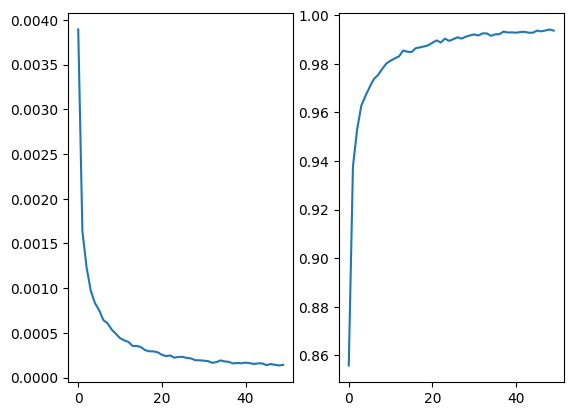

In [47]:
fit, (ax1,ax2)=plt.subplots(1,2)
ax1.plot(loss1)
ax2.plot(acc1)

In [49]:
pred=[]
label=[]

# 모델을 평가모드설정(생략해도됨) -> dropout 이 off 됨
model.eval()
# inference_mode : gradient 비활성 -> 메모리 절약
with torch.inference_mode():
  for i,j in test_loader:
    z=model(i.view(-1, 28*28))
    val, y_pred=torch.max(z,1)
    # 리스트에 배치단위(128) 결과들을 각각 이어붙인다.
    pred.extend(y_pred.numpy())
    label.extend(j.numpy())

# 모델이 정답을 맞춘 이미지 위치
# pre=[2,8,1,0,4]
# label=[2,6,1,0,4]
# np.nonzero([True, False, True, True, True]) => True인 값 인덱스 반환 -> 0,2,3,4
answer=np.nonzero(np.array(pred)==np.array(label))[0]
incorrect=np.nonzero(np.array(pred)!=np.array(label))[0]

#전체 샘플 중 맞춘 비율
print(len(answer)/len(pred)*100)


98.14


In [50]:
np.array(pred)==np.array(label)

array([ True,  True,  True, ...,  True,  True,  True])

In [51]:
arr=np.array([True, False, True])
np.nonzero(arr)[0]

array([0, 2])

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

[[ 970    1    0    2    0    2    2    0    1    2]
 [   0 1127    2    1    0    1    2    1    1    0]
 [   2    1 1015    4    0    0    2    4    4    0]
 [   1    0    5  987    0    5    0    5    4    3]
 [   0    0    4    0  957    0    5    1    2   13]
 [   2    0    0    7    1  872    3    1    3    3]
 [   2    2    0    1    2    3  944    0    4    0]
 [   2    4   10    0    0    0    0 1004    0    8]
 [   2    1    3    5    2    1    2    3  950    5]
 [   2    2    0    4    4    3    0    6    0  988]]
98.9795918367347
99.29515418502203
98.35271317829456
97.72277227722772
97.45417515274949
97.75784753363229
98.53862212943632
97.66536964980544
97.5359342915811
97.9187314172448


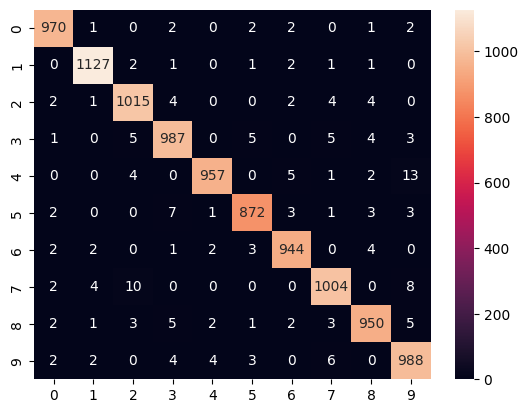

In [54]:
con_mtx=confusion_matrix(label, pred)
print(con_mtx)
# 각 셀에 숫자표시(annot), 정수형으로 표시(fmt='d')
sns=sns.heatmap(con_mtx, annot=True, fmt='d')
for i in range(10):
  # con_mtx[i][i] : 실제 i인 샘플 중 올바르게 예측된 수
  # con_mtx[i].sum() : 실제 i클래스의 전체 샘플 수
  # => 각 클래스별로 정확도 계산함
  print(con_mtx[i][i]/con_mtx[i].sum()*100)

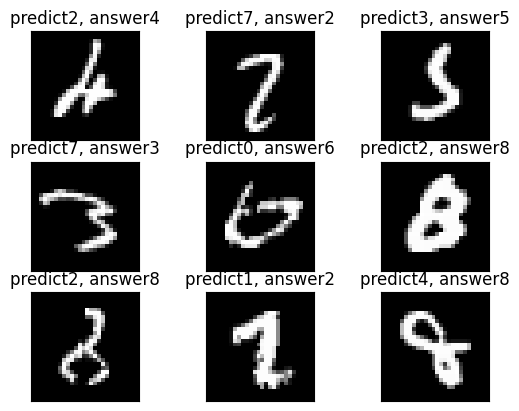

In [60]:
# 맞춘 이미지 / 못맞춘 이미지
# 모델이 잘못 예측한 숫자들 출력
for i, idx in enumerate(incorrect[:9]):
  plt.subplot(3,3,i+1)
  # 인덱스에 해당하는 테스트 이미지(2ㅇ 이미지 형태로 변환)
  plt.imshow(test_data[idx][0].view(28,28), cmap='gray')
  plt.title("predict{}, answer{}".format(pred[idx], label[idx]))
  plt.xticks([])
  plt.yticks([])
plt.show()